**1_EDA**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# علشان الرسومات تظهر بشكل أوضح
plt.style.use("ggplot")

# عرض جميع الأعمدة
pd.set_option("display.max_columns", None)

In [ ]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

In [ ]:
train.head()

,date_time,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
0,2012-10-02 09:00:00,NaN,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
1,2012-10-02 10:00:00,NaN,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2,2012-10-02 11:00:00,NaN,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
3,2012-10-02 12:00:00,NaN,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
4,2012-10-02 13:00:00,NaN,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918


In [ ]:
print("Rows and Columns:", train.shape)

Rows and Columns: (33750, 15)


In [ ]:
train.columns

Index(['date_time', 'is_holiday', 'air_pollution_index', 'humidity',
       'wind_speed', 'wind_direction', 'visibility_in_miles', 'dew_point',
       'temperature', 'rain_p_h', 'snow_p_h', 'clouds_all', 'weather_type',
       'weather_description', 'traffic_volume'],
      dtype='object')

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33750 entries, 0 to 33749
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date_time            33750 non-null  object 
 1   is_holiday           43 non-null     object 
 2   air_pollution_index  33750 non-null  int64  
 3   humidity             33750 non-null  int64  
 4   wind_speed           33750 non-null  int64  
 5   wind_direction       33750 non-null  int64  
 6   visibility_in_miles  33750 non-null  int64  
 7   dew_point            33750 non-null  int64  
 8   temperature          33750 non-null  float64
 9   rain_p_h             33750 non-null  float64
 10  snow_p_h             33750 non-null  float64
 11  clouds_all           33750 non-null  int64  
 12  weather_type         33750 non-null  object 
 13  weather_description  33750 non-null  object 
 14  traffic_volume       33750 non-null  int64  
dtypes: float64(3), int64(8), object(4)
m

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
air_pollution_index,33750.0,154.841422,83.735515,10.0,83.00,155.00,228.00,299.00
humidity,33750.0,71.209007,16.852248,13.0,60.00,72.00,85.00,100.00
wind_speed,33750.0,3.378193,2.055792,0.0,2.00,3.00,5.00,16.00
wind_direction,33750.0,199.471852,99.841088,0.0,130.00,200.00,290.00,360.00
visibility_in_miles,33750.0,4.989748,2.570021,1.0,3.00,5.00,7.00,9.00
dew_point,33750.0,4.989748,2.570021,1.0,3.00,5.00,7.00,9.00
temperature,33750.0,280.069587,13.415256,0.0,271.72,280.15,290.62,308.24
rain_p_h,33750.0,0.448739,53.526500,0.0,0.00,0.00,0.00,9831.30
snow_p_h,33750.0,0.000318,0.009760,0.0,0.00,0.00,0.00,0.51
clouds_all,33750.0,50.458785,38.871734,0.0,1.00,64.00,90.00,100.00


In [ ]:
train.isnull().sum()

,0
date_time,0
is_holiday,33707
air_pollution_index,0
humidity,0
wind_speed,0
wind_direction,0
visibility_in_miles,0
dew_point,0
temperature,0
rain_p_h,0


**Univariate Analysis**

Target         
عايزين نشوف توزيعه    

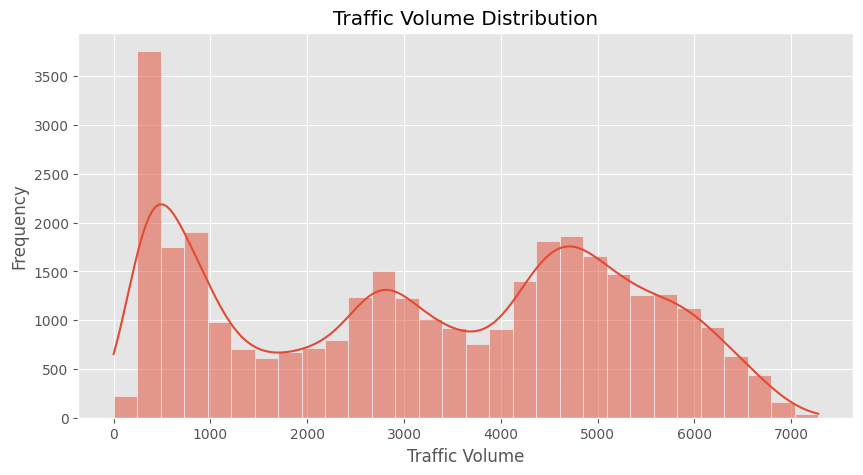

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(train["traffic_volume"], bins=30, kde=True)

plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.show()

True

يبقى عندنا عمود مكرر %100

In [ ]:
train["visibility_in_miles"].equals(train["dew_point"])

True

Numerical Features

In [ ]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns

num_cols

Index(['air_pollution_index', 'humidity', 'wind_speed', 'wind_direction',
       'visibility_in_miles', 'dew_point', 'temperature', 'rain_p_h',
       'snow_p_h', 'clouds_all', 'traffic_volume'],
      dtype='object')

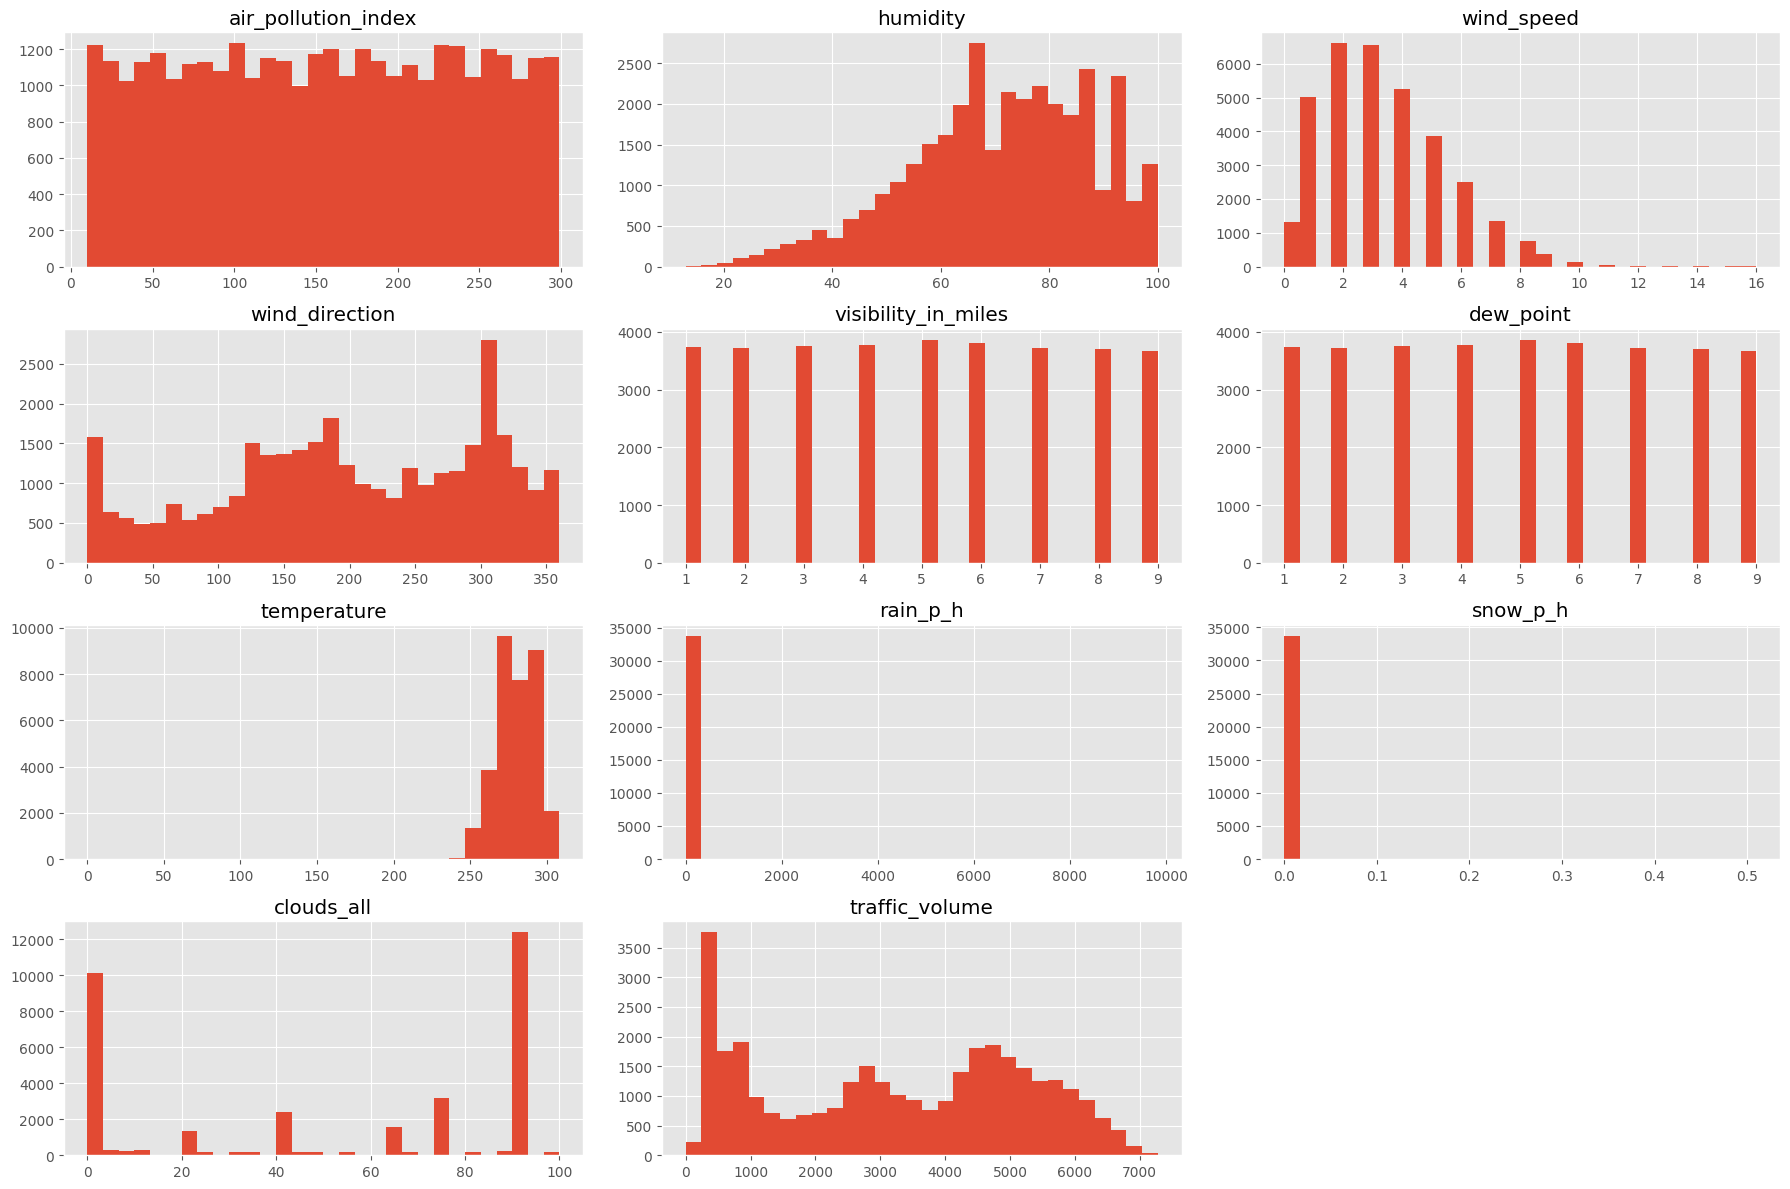

In [ ]:
train[num_cols].hist(figsize=(18,12), bins=30)

plt.tight_layout()
plt.show()

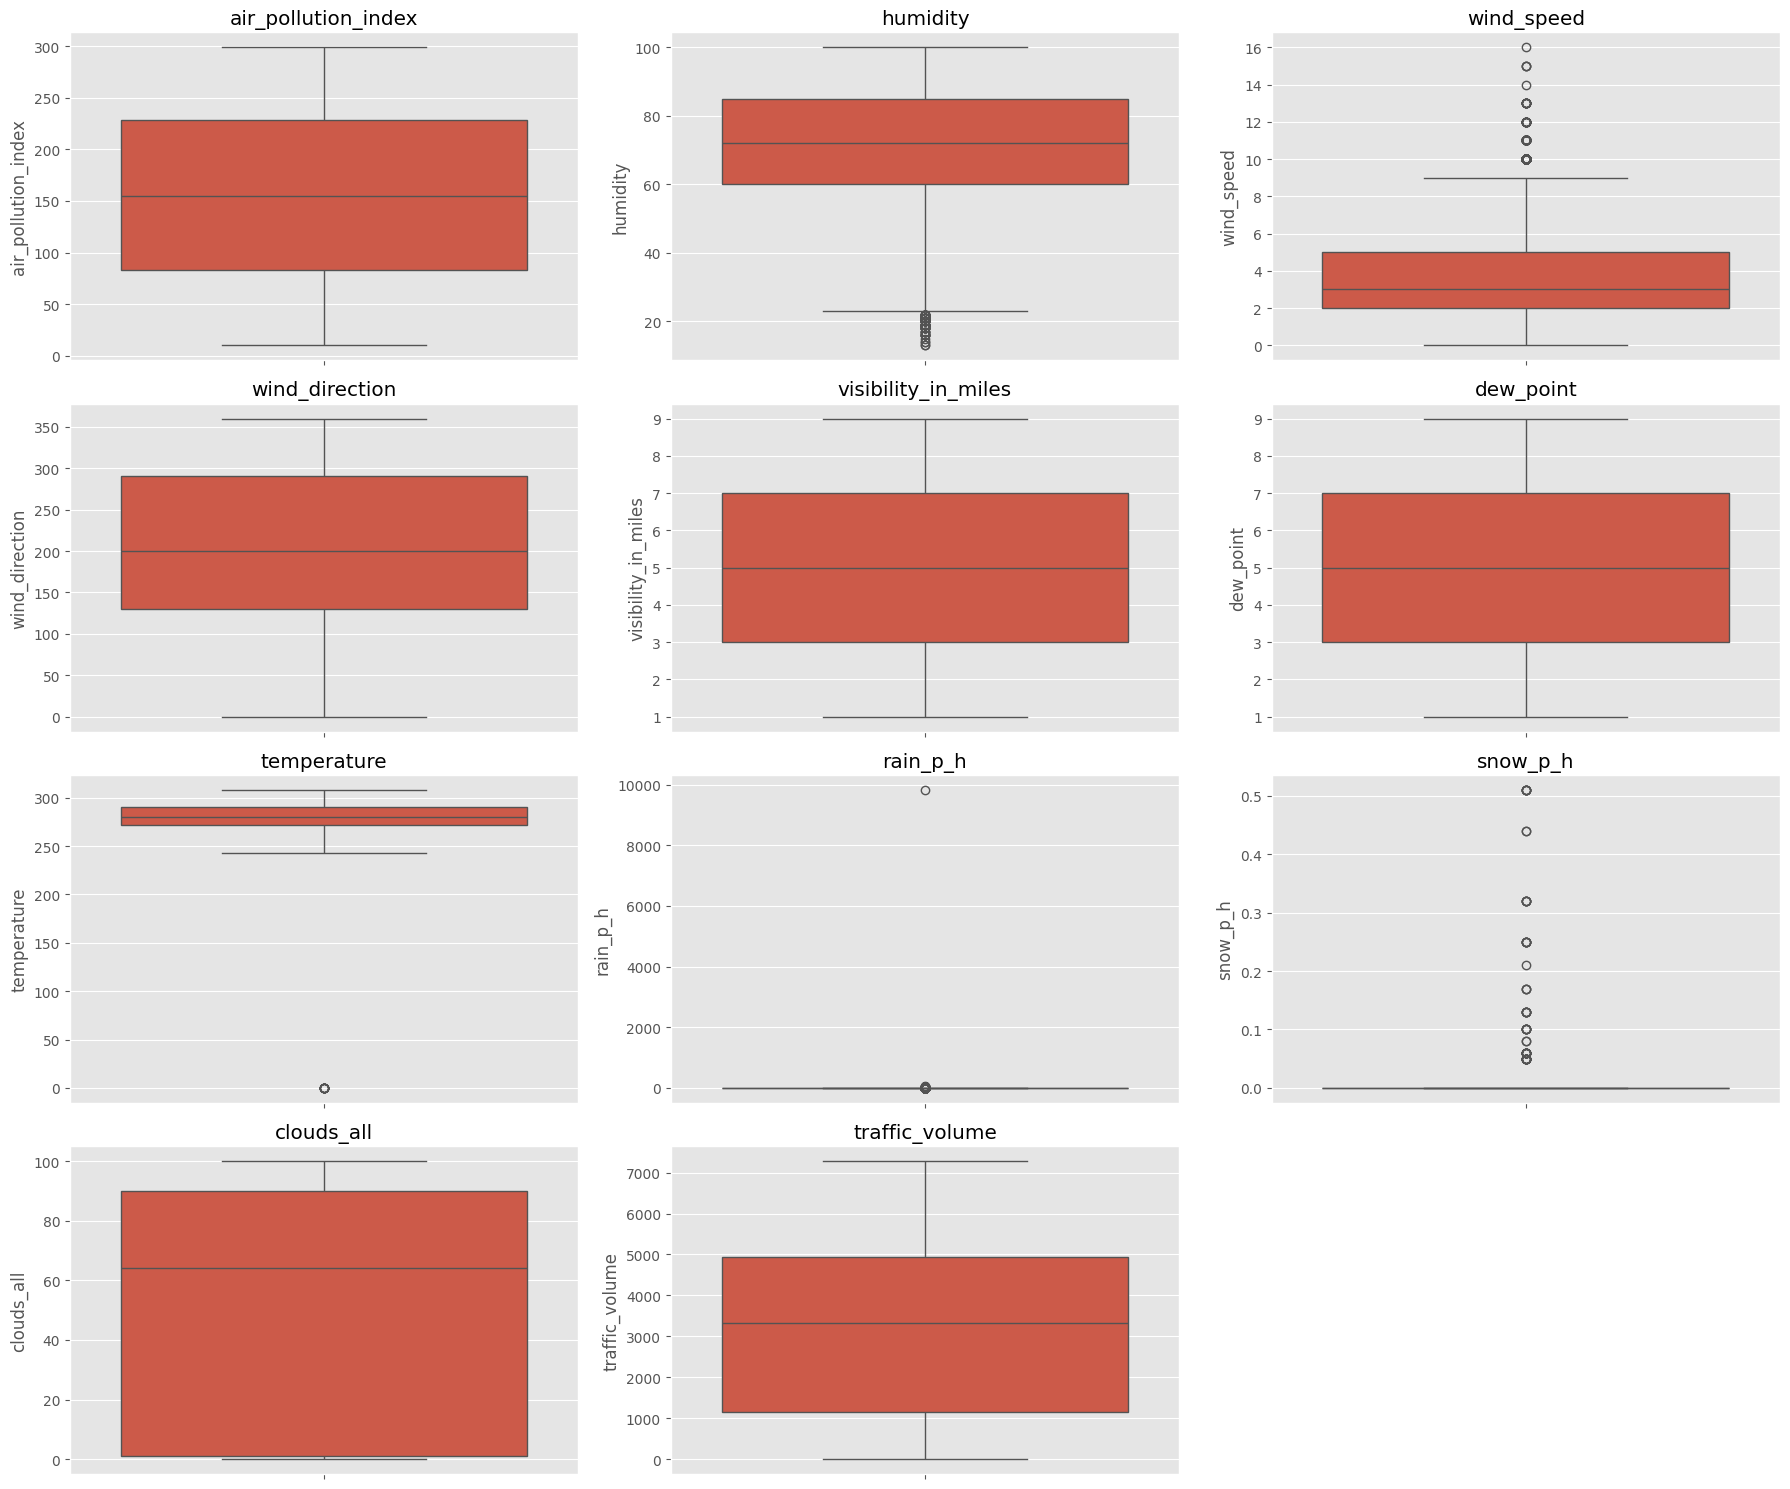

In [ ]:
num_cols = train.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Categorical Features

In [ ]:
train["weather_type"].value_counts()

,count
weather_type,
Clouds,11213
Clear,9233
Mist,4047
Rain,3940
Snow,2070
Drizzle,1204
Haze,902
Fog,567
Thunderstorm,553


In [ ]:
train["weather_type"].value_counts(normalize=True) * 100

,proportion
weather_type,
Clouds,33.223704
Clear,27.357037
Mist,11.991111
Rain,11.674074
Snow,6.133333
Drizzle,3.567407
Haze,2.672593
Fog,1.680000
Thunderstorm,1.638519


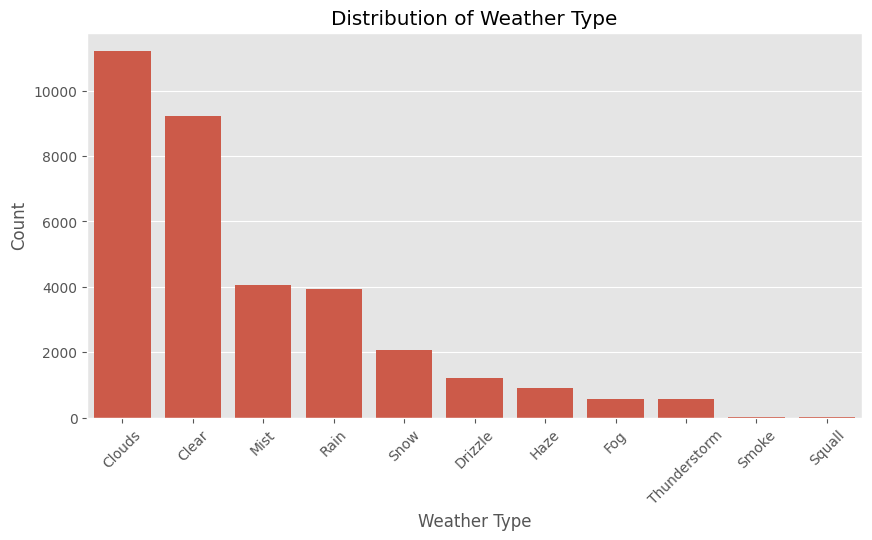

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="weather_type",
    order=train["weather_type"].value_counts().index
)

plt.title("Distribution of Weather Type")
plt.xlabel("Weather Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [ ]:
train["weather_description"].value_counts().head(10)

,count
weather_description,
sky is clear,7524
mist,4047
overcast clouds,3972
broken clouds,3379
light rain,2442
scattered clouds,2294
Sky is Clear,1709
few clouds,1568
light snow,1280


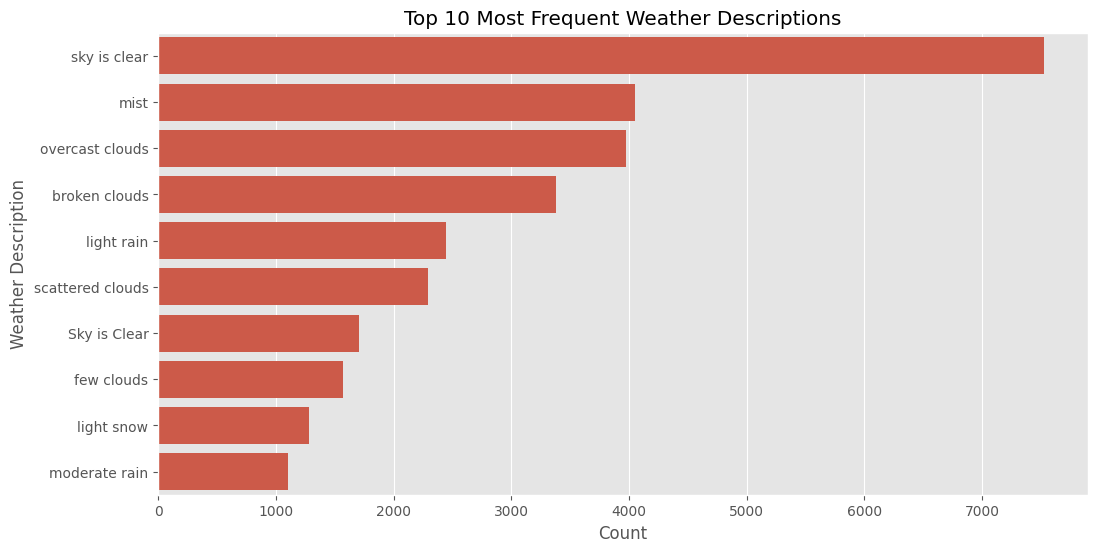

In [ ]:
plt.figure(figsize=(12,6))

top_desc = train["weather_description"].value_counts().head(10)

sns.barplot(
    x=top_desc.values,
    y=top_desc.index
)

plt.title("Top 10 Most Frequent Weather Descriptions")
plt.xlabel("Count")
plt.ylabel("Weather Description")

plt.show()

In [ ]:
train["is_holiday"].value_counts(dropna=False)

,count
is_holiday,
NaN,33707
Thanksgiving Day,5
New Years Day,5
Christmas Day,5
Veterans Day,4
Columbus Day,4
Washingtons Birthday,4
Labor Day,4
Memorial Day,3


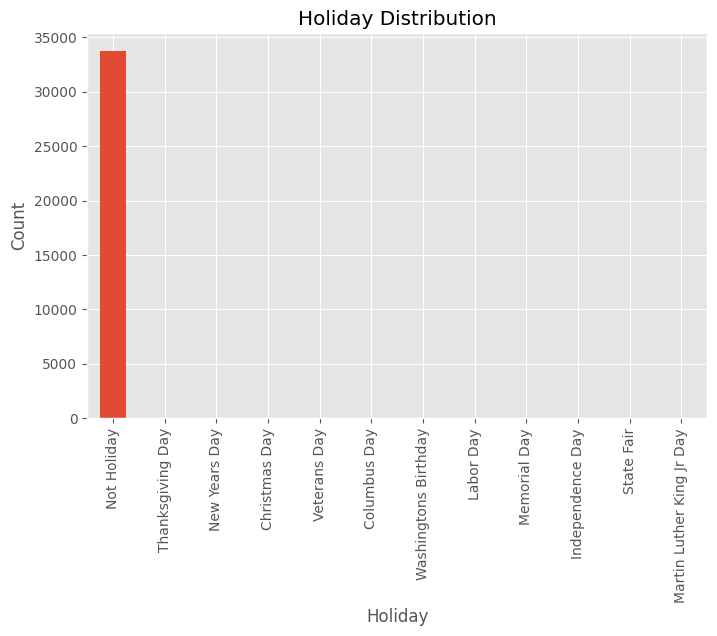

In [ ]:
plt.figure(figsize=(8,5))

train["is_holiday"].fillna("Not Holiday").value_counts().plot(kind="bar")

plt.title("Holiday Distribution")
plt.xlabel("Holiday")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

**Bivariate Analysis**

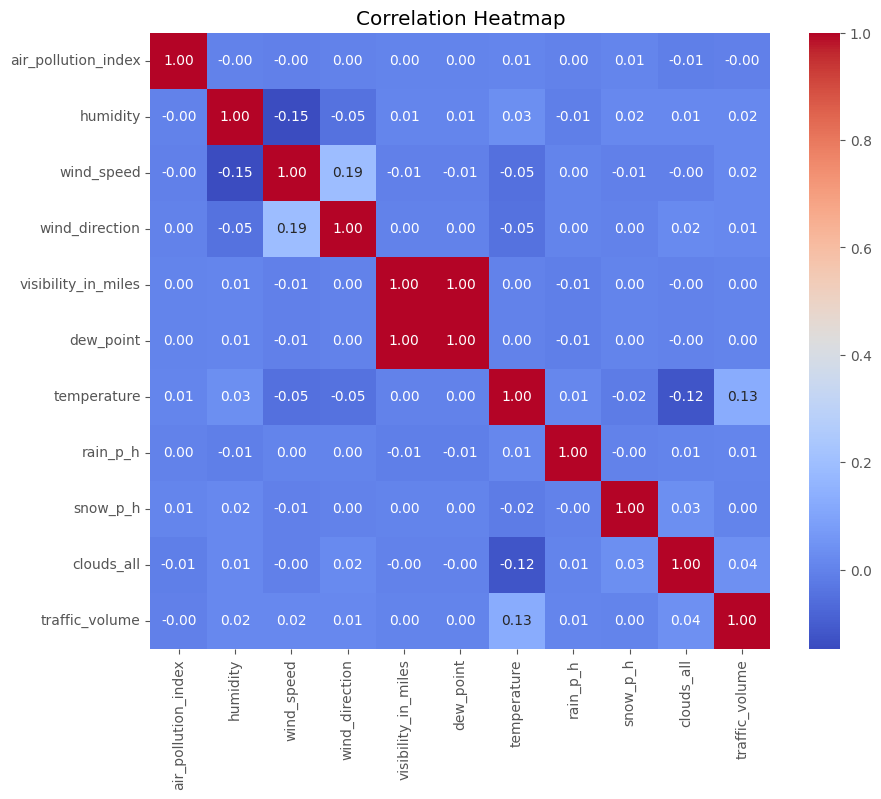

In [ ]:
plt.figure(figsize=(10,8))

corr = train.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

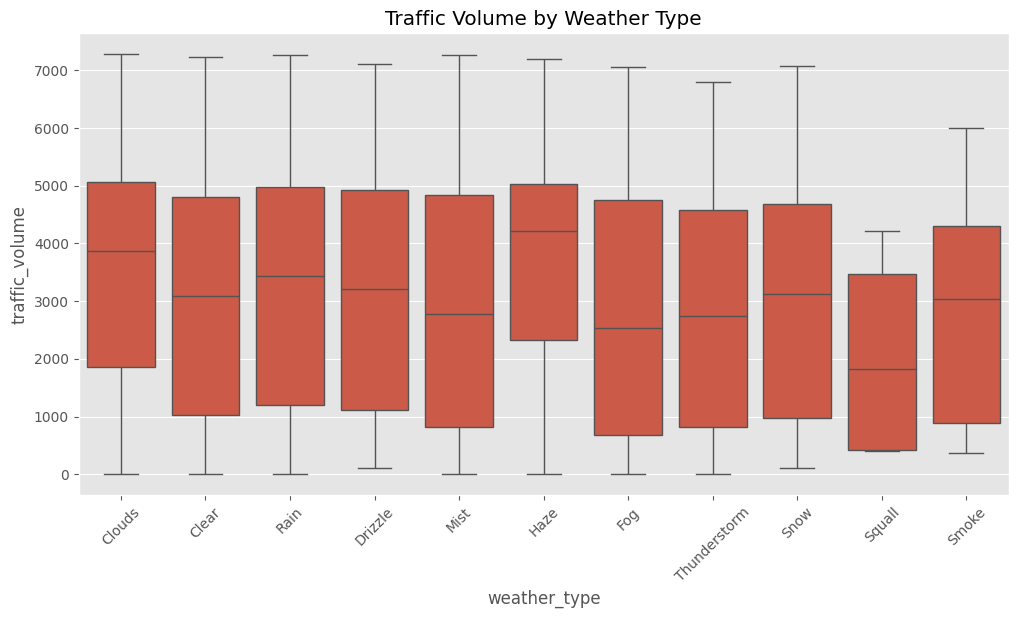

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=train,
    x="weather_type",
    y="traffic_volume"
)

plt.xticks(rotation=45)

plt.title("Traffic Volume by Weather Type")

plt.show()

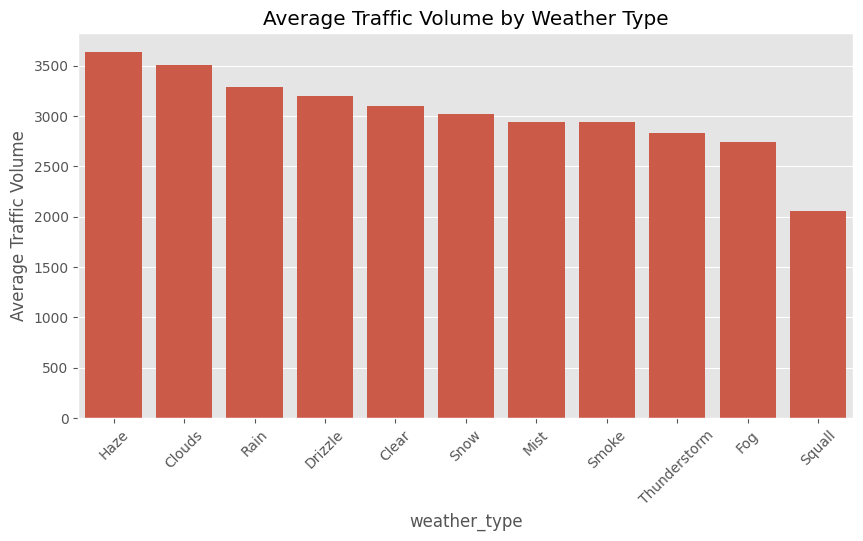

In [ ]:
avg_weather = train.groupby("weather_type")["traffic_volume"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_weather.index,
    y=avg_weather.values
)

plt.xticks(rotation=45)

plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Weather Type")

plt.show()

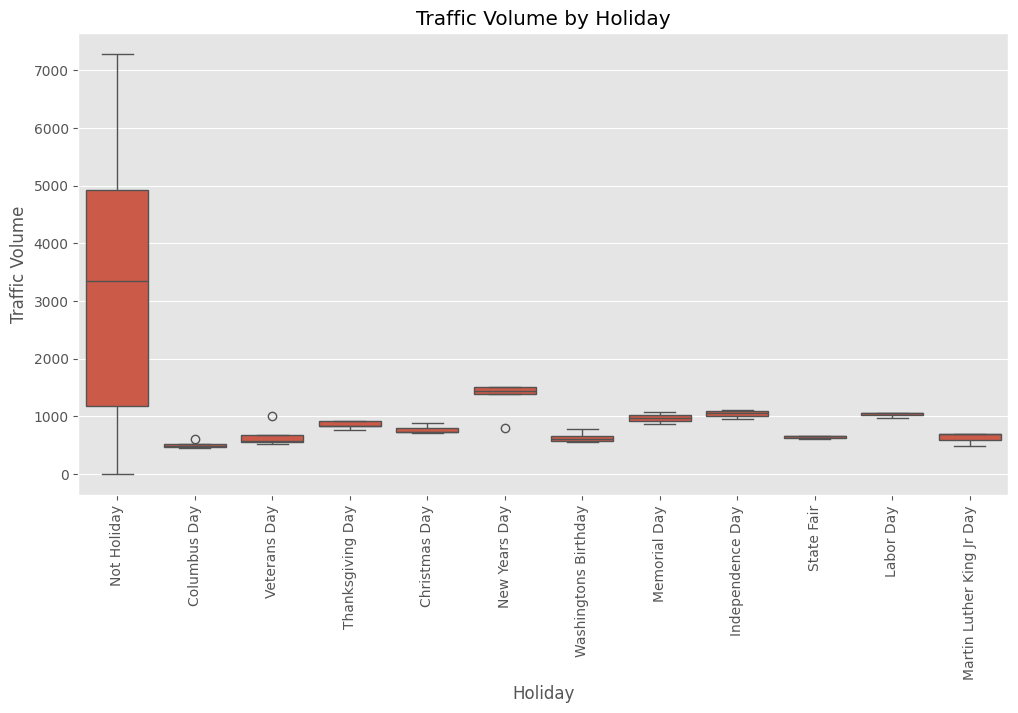

In [ ]:
holiday = train.copy()

holiday["is_holiday"] = holiday["is_holiday"].fillna("Not Holiday")

plt.figure(figsize=(12,6))

sns.boxplot(
    data=holiday,
    x="is_holiday",
    y="traffic_volume"
)

plt.xticks(rotation=90)

plt.title("Traffic Volume by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Traffic Volume")

plt.show()

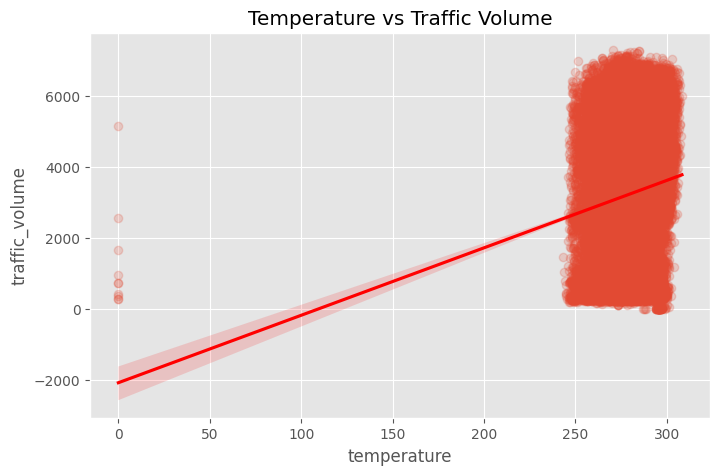

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=train,
    x="temperature",
    y="traffic_volume",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Temperature vs Traffic Volume")

plt.show()

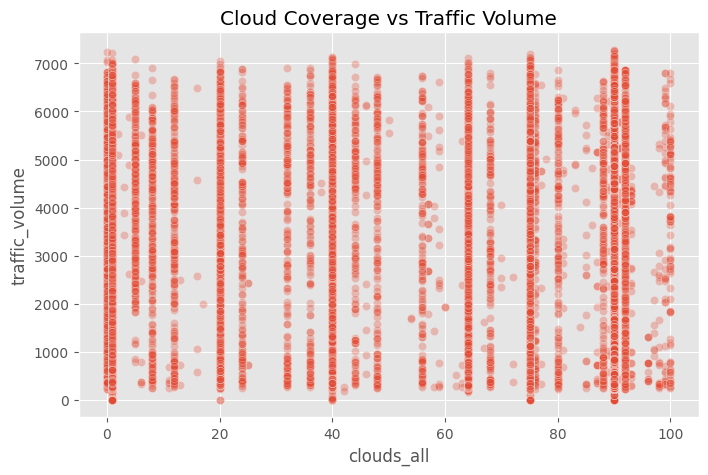

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train,
    x="clouds_all",
    y="traffic_volume",
    alpha=0.3
)

plt.title("Cloud Coverage vs Traffic Volume")

plt.show()

**Feature Extraction**

⏰ Date & Time Analysis

In [ ]:
train["date_time"] = pd.to_datetime(train["date_time"])

استخراج الساعة

In [ ]:
train["hour"] = train["date_time"].dt.hour

اليوم في الأسبوع

In [ ]:
train["day_of_week"] = train["date_time"].dt.day_name()

رقم اليوم في الأسبوع

In [ ]:
train["day_num"] = train["date_time"].dt.dayofweek

الشهر

In [ ]:
train["month"] = train["date_time"].dt.month

السنة

In [ ]:
train["year"] = train["date_time"].dt.year

Weekend

In [ ]:
train["is_weekend"] = train["date_time"].dt.dayofweek.isin([5, 6])

In [ ]:
train.head()

,date_time,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume,hour,day_of_week,day_num,month,year,is_weekend
0,2012-10-02 09:00:00,NaN,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,9,Tuesday,1,10,2012,False
1,2012-10-02 10:00:00,NaN,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516,10,Tuesday,1,10,2012,False
2,2012-10-02 11:00:00,NaN,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,11,Tuesday,1,10,2012,False
3,2012-10-02 12:00:00,NaN,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,12,Tuesday,1,10,2012,False
4,2012-10-02 13:00:00,NaN,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918,13,Tuesday,1,10,2012,False


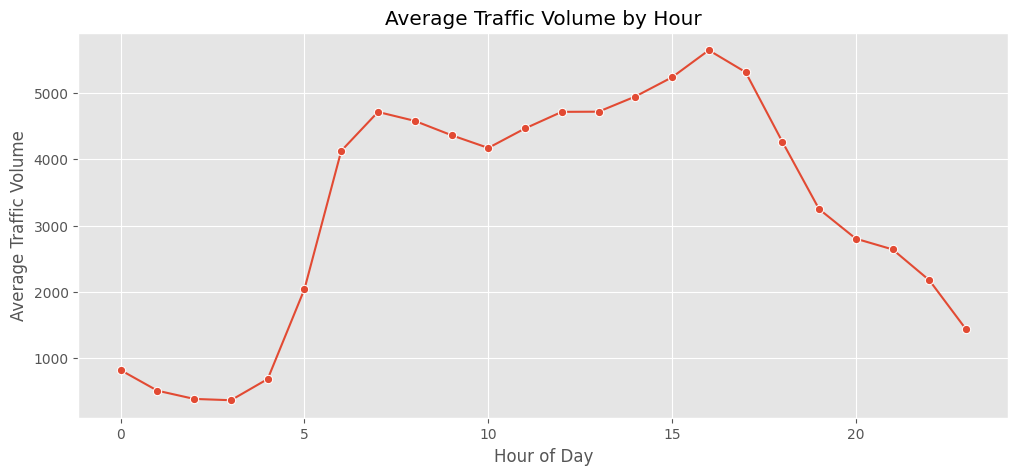

In [ ]:
hourly_traffic = train.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_traffic.index,
    y=hourly_traffic.values,
    marker="o"
)

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")

plt.show()

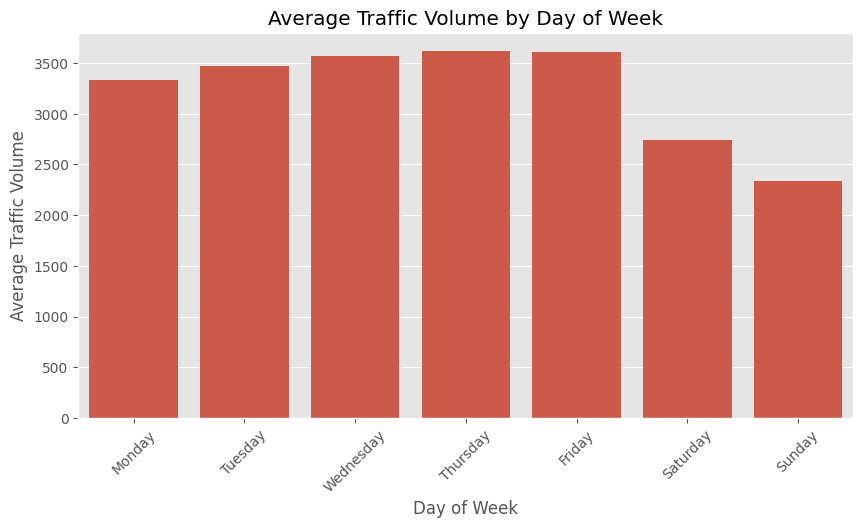

In [ ]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_traffic = (
    train.groupby("day_of_week")["traffic_volume"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=day_traffic.index,
    y=day_traffic.values
)

plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Traffic Volume")
plt.xticks(rotation=45)

plt.show()

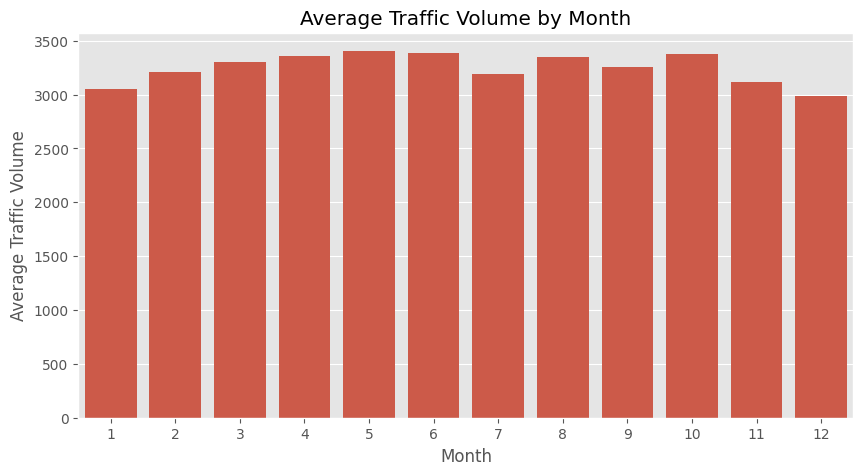

In [ ]:
month_traffic = train.groupby("month")["traffic_volume"].mean()

plt.figure(figsize=(10,5))

sns.barplot(
    x=month_traffic.index,
    y=month_traffic.values
)

plt.title("Average Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Traffic Volume")

plt.show()

In [ ]:
train["is_weekend"] = train["date_time"].dt.dayofweek.isin([5, 6])

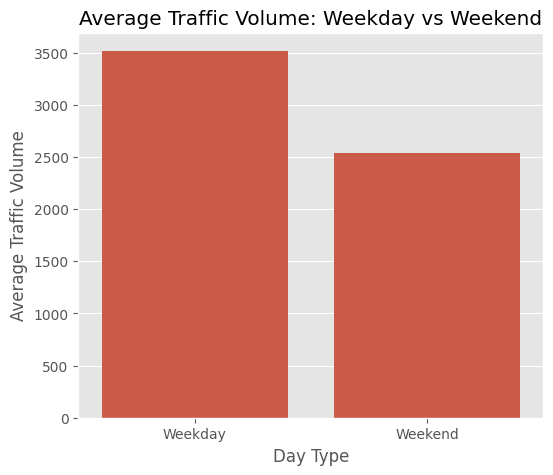

In [ ]:
weekend_traffic = train.groupby("is_weekend")["traffic_volume"].mean()

plt.figure(figsize=(6,5))

sns.barplot(
    x=["Weekday", "Weekend"],
    y=weekend_traffic.values
)

plt.title("Average Traffic Volume: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Traffic Volume")

plt.show()

**Preprocessing**

Step 1: Handle Missing Values

In [ ]:
# Fill missing values
train["is_holiday"] = train["is_holiday"].fillna("Not Holiday")
test["is_holiday"] = test["is_holiday"].fillna("Not Holiday")

# Convert to binary
train["is_holiday"] = (train["is_holiday"] != "Not Holiday").astype(int)
test["is_holiday"] = (test["is_holiday"] != "Not Holiday").astype(int)

# Check the result
train["is_holiday"].value_counts()


,count
is_holiday,
0,33707
1,43


  Feature Extraction
  
 كمانTest لل

In [ ]:
train["date_time"] = pd.to_datetime(train["date_time"])
test["date_time"] = pd.to_datetime(test["date_time"])


train["hour"] = train["date_time"].dt.hour
test["hour"] = test["date_time"].dt.hour

train["day_of_week"] = train["date_time"].dt.dayofweek
test["day_of_week"] = test["date_time"].dt.dayofweek

train["month"] = train["date_time"].dt.month
test["month"] = test["date_time"].dt.month

train["year"] = train["date_time"].dt.year
test["year"] = test["date_time"].dt.year

train["is_weekend"] = train["day_of_week"].isin([5,6]).astype(int)
test["is_weekend"] = test["day_of_week"].isin([5,6]).astype(int)

In [ ]:
def rush_hour(hour):
    if 7 <= hour <= 9 or 16 <= hour <= 19:
        return 1
    else:
        return 0


train["rush_hour"] = train["hour"].apply(rush_hour)
test["rush_hour"] = test["hour"].apply(rush_hour)

In [ ]:
train["day"] = train["date_time"].dt.day
test["day"] = test["date_time"].dt.day


train["rush_hour"] = train["hour"].apply(
    lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0
)

test["rush_hour"] = test["hour"].apply(
    lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0
)

Cyclic Feature

ساعة اليوم بشكل دائري

لأن الساعة 23 و الساعة 0 قريبين من بعض، لكن الموديل شايفهم بعيدين

In [ ]:
train["hour_sin"] = np.sin(2 * np.pi * train["hour"] / 24)
train["hour_cos"] = np.cos(2 * np.pi * train["hour"] / 24)

test["hour_sin"] = np.sin(2 * np.pi * test["hour"] / 24)
test["hour_cos"] = np.cos(2 * np.pi * test["hour"] / 24)

In [ ]:
train["is_peak"] = train["hour"].isin([7,8,9,16,17,18,19]).astype(int)

test["is_peak"] = test["hour"].isin([7,8,9,16,17,18,19]).astype(int)

Drop Columns

In [ ]:
train = train.sort_values("date_time")

In [ ]:
drop_cols = [
    "date_time",
    "visibility_in_miles",
    "dew_point"
]

train.drop(columns=drop_cols, inplace=True, errors="ignore")
test.drop(columns=drop_cols, inplace=True, errors="ignore")

In [ ]:
train.columns

Index(['is_holiday', 'air_pollution_index', 'humidity', 'wind_speed',
       'wind_direction', 'temperature', 'rain_p_h', 'snow_p_h', 'clouds_all',
       'weather_type', 'weather_description', 'traffic_volume', 'hour',
       'day_of_week', 'day_num', 'month', 'year', 'is_weekend', 'rush_hour',
       'day', 'hour_sin', 'hour_cos', 'is_peak'],
      dtype='object')

نفصل X و y

In [ ]:
X = train.drop("traffic_volume", axis=1)
y = train["traffic_volume"]

Train Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

تحديد الأعمدة

In [ ]:
cat_cols = X_train.select_dtypes(include="object").columns

num_cols = X_train.select_dtypes(
    include=["int64","float64"]
).columns
print(cat_cols)
print(num_cols)

Index(['weather_type', 'weather_description'], dtype='object')
Index(['is_holiday', 'air_pollution_index', 'humidity', 'wind_speed',
       'wind_direction', 'temperature', 'rain_p_h', 'snow_p_h', 'clouds_all',
       'is_weekend', 'rush_hour', 'hour_sin', 'hour_cos', 'is_peak'],
      dtype='object')


 عمل الـ Preprocessor

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [ ]:
train.head()

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume,hour,day_of_week,day_num,month,year,is_weekend,rush_hour,day,hour_sin,hour_cos,is_peak
0,0,121,89,2,329,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,9,1,1,10,2012,0,1,2,7.071068e-01,-0.707107,1
1,0,178,67,3,330,289.36,0.0,0.0,75,Clouds,broken clouds,4516,10,1,1,10,2012,0,0,2,5.000000e-01,-0.866025,0
2,0,113,66,3,329,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,11,1,1,10,2012,0,0,2,2.588190e-01,-0.965926,0
3,0,20,66,3,329,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,12,1,1,10,2012,0,0,2,1.224647e-16,-1.000000,0
4,0,281,65,3,329,291.14,0.0,0.0,75,Clouds,broken clouds,4918,13,1,1,10,2012,0,0,2,-2.588190e-01,-0.965926,0


In [ ]:
X_train.dtypes

,0
is_holiday,int64
air_pollution_index,int64
humidity,int64
wind_speed,int64
wind_direction,int64
temperature,float64
rain_p_h,float64
snow_p_h,float64
clouds_all,int64
weather_type,object


**Models**

Linear Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2:", r2_score(y_val, lr_pred))
print("MAE:", mean_absolute_error(y_val, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, lr_pred)))

R2: 0.747845502165269
MAE: 762.0176931347157
RMSE: 1003.502791786594


XGBoost

In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model",
         XGBRegressor(
             n_estimators=1000,
             learning_rate=0.03,
             max_depth=8,
             subsample=0.8,
             colsample_bytree=0.8,
             random_state=42
         ))
    ]
)

In [ ]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['is_holiday', 'air_pollution_index', 'humidity', 'wind_speed',
       'wind_direction', 'temperature', 'rain_p_h', 'snow_p_h', 'clouds_all',
       'is_weekend', 'rush_hour', 'hour_sin', 'hour_cos', 'is_peak'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['w...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=1000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred = xgb_model.predict(X_val)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.9404846429824829
MAE: 308.46014404296875
RMSE: 487.52822033703853


Hyperparameter Tuning

In [ ]:
param_grid_xgb = {
    "model__n_estimators": [500, 1000],
    "model__max_depth": [6, 8],
    "model__learning_rate": [0.03, 0.05]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

In [ ]:
grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['is_holiday', 'air_pollution_index', 'humidity', 'wind_speed',
       'wind_direction', 'temperature', 'rain_p_h', 'snow_p_h', 'clouds_all',
       'is_weekend', 'rush_hour', 'hour_sin', 'hour_cos', 'is_peak'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle...
                                                     max_cat_threshold=None,
                                                     max_cat_to_onehot=None,
                                                     max_delta_step=None,
                                                     max_depth=8,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=1000,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.03, 0.05],
                         'model__max_depth': [6, 8],
                         'model__n_estimators': [500, 1000]},
             scoring='r2')

In [ ]:
print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)

Best Parameters: {'model__learning_rate': 0.03, 'model__max_depth': 8, 'model__n_estimators': 1000}
Best CV Score: 0.9342825611432394


In [ ]:
best_xgb = grid_xgb.best_estimator_

xgb_pred = best_xgb.predict(X_val)

print("R2:", r2_score(y_val, xgb_pred))
print("MAE:", mean_absolute_error(y_val, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, xgb_pred)))

R2: 0.9404846429824829
MAE: 308.46014404296875
RMSE: 487.52822033703853


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['is_holiday', 'air_pollution_index', 'humidity', 'wind_speed',
       'wind_direction', 'temperature', 'rain_p_h', 'snow_p_h', 'clouds_all',
       'is_weekend', 'rush_hour', 'hour_sin', 'hour_cos', 'is_peak'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['weather_type', 'weather_description'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
rf_pred = rf_model.predict(X_val)

print("R2:", r2_score(y_val, rf_pred))
print("MAE:", mean_absolute_error(y_val, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, rf_pred)))

R2: 0.9323424802859009
MAE: 320.8663007407407
RMSE: 519.8083622069024


Hyperparameter Tuning ـRandom Forest ل

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, None],
    "model__min_samples_split": [2, 5]
}

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=4,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

print(random_rf.best_params_)
print(random_rf.best_score_)

{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': None}
0.9267656402980627


In [ ]:
best_rf = random_rf.best_estimator_

rf_pred = best_rf.predict(X_val)

print("R2:", r2_score(y_val, rf_pred))
print("MAE:", mean_absolute_error(y_val, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, rf_pred)))

R2: 0.9324571731632378
MAE: 320.71408847595245
RMSE: 519.3675863358295


مقارنة الموديلز

In [ ]:

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "R2": [
        0.747845502165269,
        0.9324571731632378,
        0.9404846429824829
    ],
    "MAE": [
        762.0176931347157,
        320.71408847595245,
        308.46014404296875
    ],
    "RMSE": [
        1003.502791786594,
        519.3675863358295,
        487.52822033703853
    ]
})

results.sort_values("R2", ascending=False)

,Model,R2,MAE,RMSE
2,XGBoost,0.940485,308.460144,487.528220
1,Random Forest,0.932457,320.714088,519.367586
0,Linear Regression,0.747846,762.017693,1003.502792
